# Student Performance Prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("student_performance.csv")

In [ ]:
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [ ]:
df.shape

(1000000, 6)

In [ ]:
df.isnull().sum()

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0


In [ ]:
df.drop(columns=['student_id'], inplace=True)

In [ ]:
# Numerical columns
num_cols = ['weekly_self_study_hours',
            'attendance_percentage',
            'class_participation',
            'total_score']

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical column
df['grade'] = df['grade'].fillna(df['grade'].mode()[0])

In [ ]:
df.isnull().sum()

,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0


In [ ]:
corr = df[['weekly_self_study_hours',
           'attendance_percentage',
           'class_participation',
           'total_score']].corr()

corr

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
weekly_self_study_hours,1.000000,-0.001008,0.001244,0.812241
attendance_percentage,-0.001008,1.000000,-0.000043,-0.001014
class_participation,0.001244,-0.000043,1.000000,0.000684
total_score,0.812241,-0.001014,0.000684,1.000000


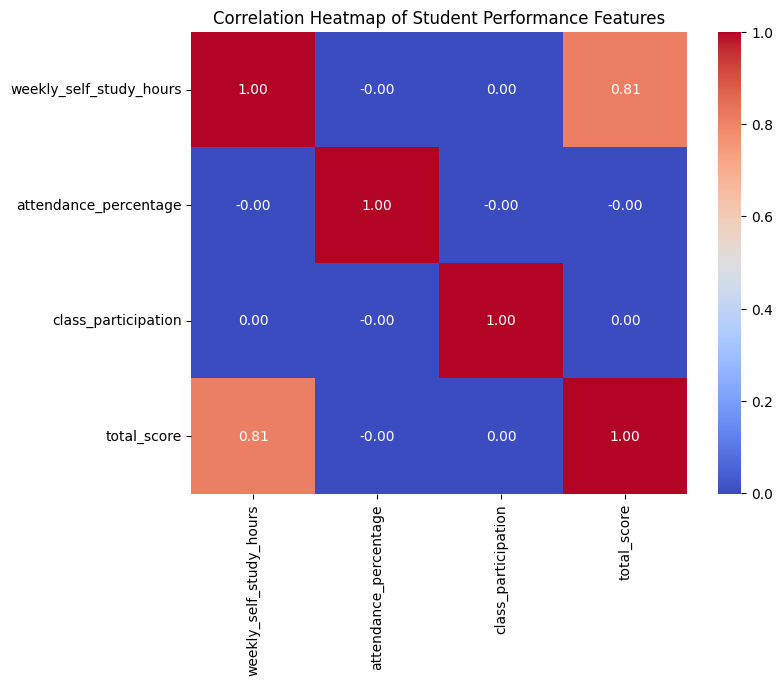

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap of Student Performance Features")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['grade_encoded'] = le.fit_transform(df['grade'])

df[['grade', 'grade_encoded']].head()

,grade,grade_encoded
0,A,0
1,B,1
2,A,0
3,A,0
4,A,0


In [ ]:
X = df[['weekly_self_study_hours',
        'attendance_percentage',
        'class_participation']]

In [ ]:
y_reg = df['total_score']

In [ ]:
y_clf = df['grade_encoded']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train_reg)

y_pred_reg = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 80.9352286743695
R2 Score: 0.6600425865640975


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train_clf)

y_pred_clf = clf.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print(classification_report(y_test_clf, y_pred_clf))


Accuracy: 0.696805
              precision    recall  f1-score   support

           0       0.83      0.89      0.86    109888
           1       0.52      0.50      0.51     51556
           2       0.51      0.45      0.48     28380
           3       0.49      0.35      0.41      8927
           4       0.00      0.00      0.00      1249

    accuracy                           0.70    200000
   macro avg       0.47      0.44      0.45    200000
weighted avg       0.68      0.70      0.69    200000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
